In [1]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 1.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
import math

In [3]:
# Charger le fichier CSV
df = pd.read_csv("/content/Raja Casablanca_RSB Berkane_3960266 (2).csv")

In [4]:
# Filtrer uniquement les périodes de jeu normales
df = df[df['period'] < 5]


In [5]:
# Séparer les données par équipe
team1_name = df['team_name'].unique()[0]
team2_name = df['team_name'].unique()[1]
team1 = df[df['team_name'] == team1_name]
team2 = df[df['team_name'] == team2_name]

<ipython-input-18-6cce5b5e50f3>:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df['pass_outcome'] = passes_df['outcome_name'].fillna("Successful")
<ipython-input-18-6cce5b5e50f3>:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df['pass_outcome'] = passes_df['outcome_name'].fillna("Successful")


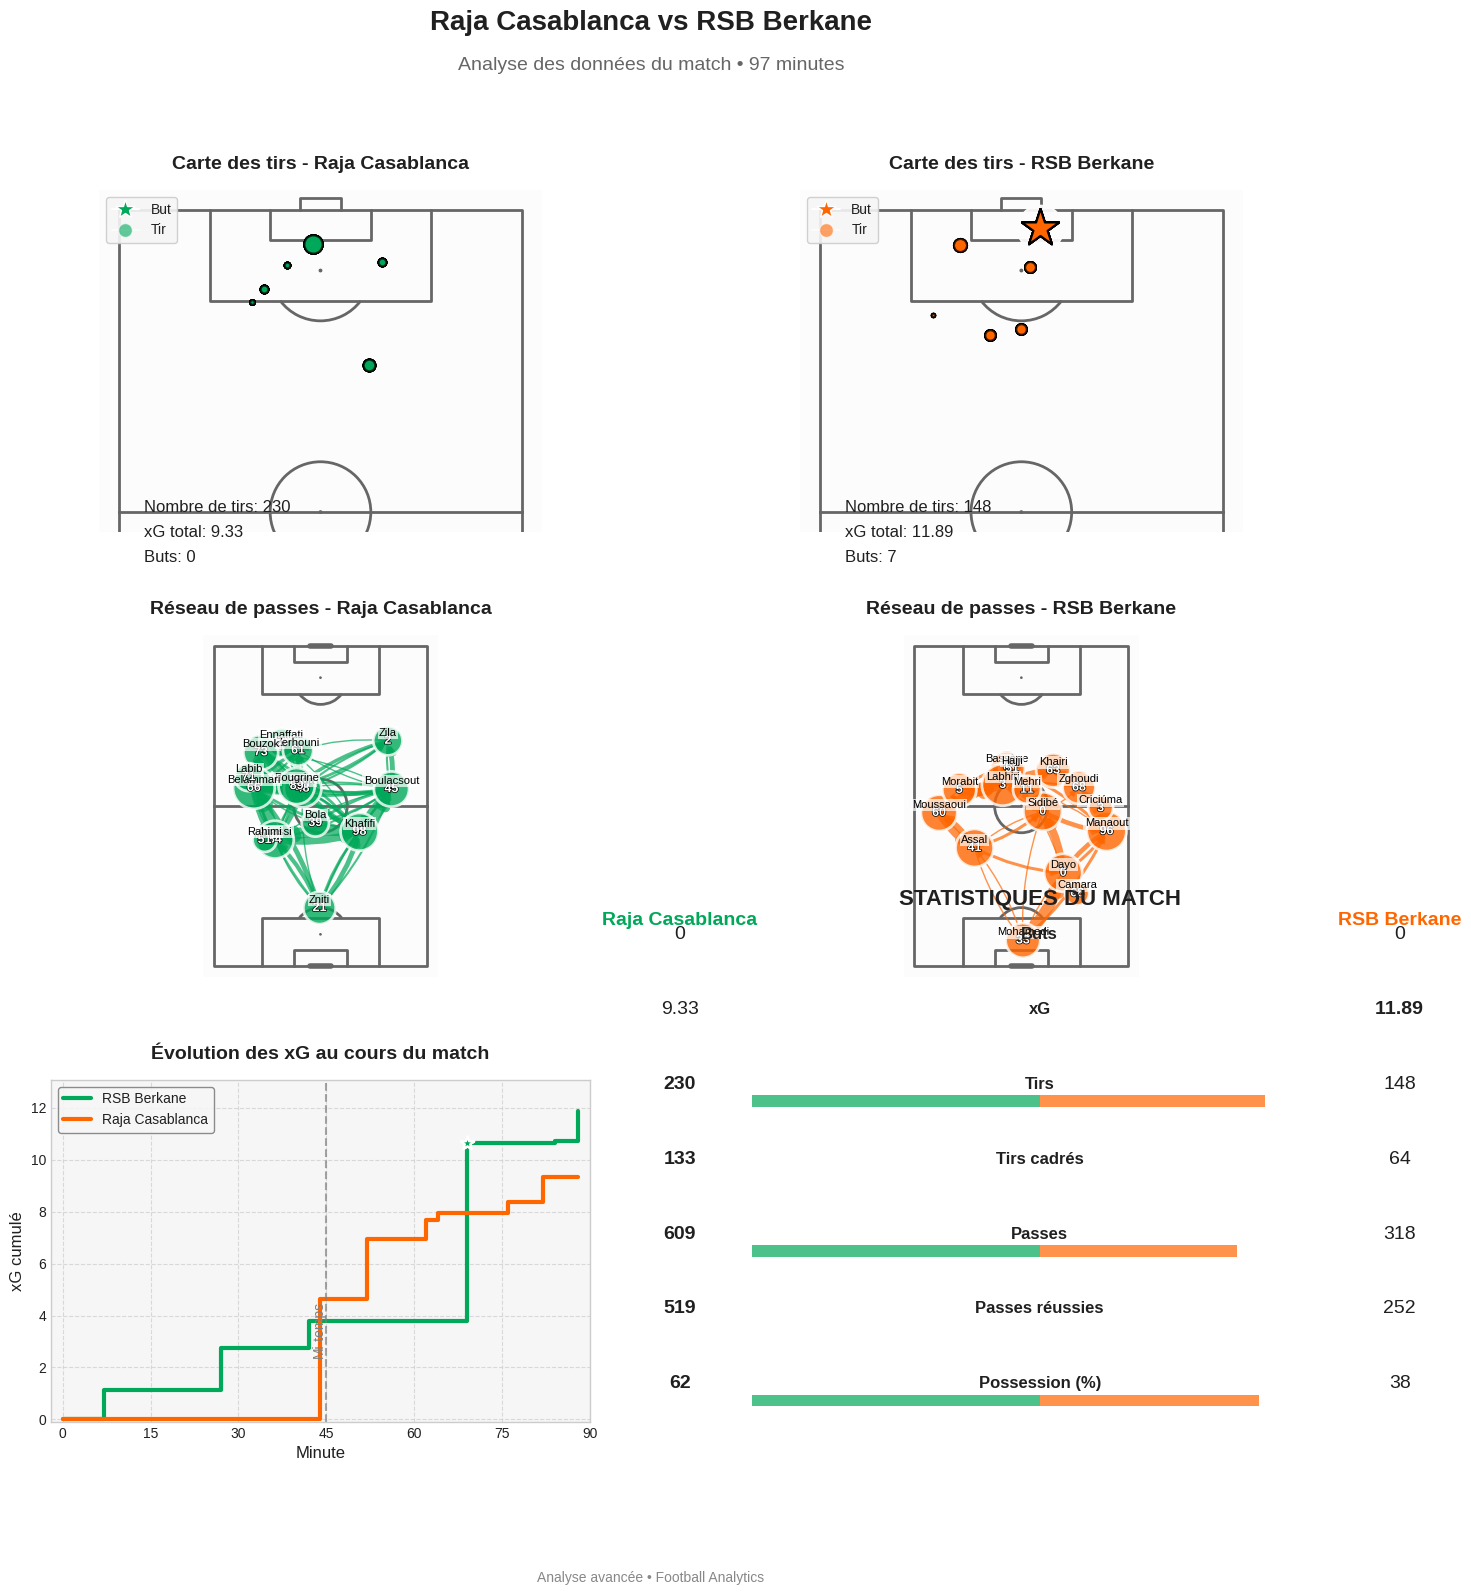

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
from mplsoccer import VerticalPitch
import matplotlib.font_manager as fm

# Charger le fichier CSV
df = pd.read_csv("/content/Raja Casablanca_RSB Berkane_3960266 (2).csv")

# Filtrer uniquement les périodes de jeu normales
df = df[df['period'] < 5]

# Séparer les données par équipe
team1_name = df['team_name'].unique()[0]
team2_name = df['team_name'].unique()[1]
team1 = df[df['team_name'] == team1_name]
team2 = df[df['team_name'] == team2_name]

# Couleurs des équipes (vert pour Raja Casablanca, et orange pour RSB Berkane)
team1_color = '#00A859'  # Vert Raja Casablanca
team2_color = '#FF6600'  # Orange RSB Berkane
background_color = '#F6F6F6'
text_color = '#202020'

# Configuration générale du style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['text.color'] = text_color
plt.rcParams['axes.labelcolor'] = text_color
plt.rcParams['xtick.color'] = text_color
plt.rcParams['ytick.color'] = text_color

def add_fancy_title(fig, title, subtitle=None):
    """Ajoute un titre élégant avec sous-titre optionnel"""
    fig.text(0.5, 0.98, title, ha='center', fontsize=20, fontweight='bold')
    if subtitle:
        fig.text(0.5, 0.955, subtitle, ha='center', fontsize=14, color='#666666')

def create_shotmap(team, ax, team_color):
    """Crée une carte des tirs plus esthétique"""
    pitch = VerticalPitch(pitch_type='statsbomb', half=True, pitch_color='#FCFCFC',
                        line_color='#666666', goal_type='box')
    pitch.draw(ax=ax)

    shots = team[team['event_type_name'] == 'Shot']
    shots = shots[['player_name', 'location_x', 'location_y', 'outcome_name', 'shot_execution_xg', 'minute']]

    # Boucle pour ajouter chaque tir
    for _, row in shots.iterrows():
        xg = row['shot_execution_xg'] if pd.notna(row['shot_execution_xg']) else 0.05

        # Utiliser des couleurs plus vives pour les buts
        if row['outcome_name'] == 'Goal':
            color = team_color
            edge_color = 'black'
            alpha = 1.0
            marker = '*'
            size = 800 * xg
            # Ajouter effet de lueur pour les buts
            glow = pitch.scatter(x=row['location_x'], y=row['location_y'], ax=ax,
                        s=size*1.4, color='white', alpha=0.3, zorder=1)
        else:
            color = team_color
            edge_color = 'black'
            alpha = 0.6
            marker = 'o'
            size = 600 * xg

        # Ajouter le tir
        pitch.scatter(
            x=row['location_x'], y=row['location_y'], ax=ax,
            s=size, color=color, edgecolors=edge_color,
            alpha=alpha, zorder=2, marker=marker,
            linewidth=1.5
        )

    # Légender le graphique
    ax.text(5, 60, f"Nombre de tirs: {len(shots)}", fontsize=12)
    ax.text(5, 55, f"xG total: {round(shots['shot_execution_xg'].sum(), 2)}", fontsize=12)
    ax.text(5, 50, f"Buts: {len(shots[shots['outcome_name'] == 'Goal'])}", fontsize=12)

    # Ajouter zone de légende
    legend_elements = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor=team_color, markersize=15, label='But'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=team_color, markersize=10, alpha=0.6, label='Tir')
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=True, framealpha=0.9)

def create_passnetwork(team, ax, team_color):
    """Crée un réseau de passes amélioré"""
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#FCFCFC', line_color='#666666')
    pitch.draw(ax=ax)

    passes_df = team.loc[team['event_type_name'] == "Pass"]
    passes_df['pass_outcome'] = passes_df['outcome_name'].fillna("Successful")
    completions = passes_df.loc[passes_df['pass_outcome'] == "Successful"]

    # Calculer les positions moyennes et le nombre de passes
    average_locs_and_count = completions.groupby('player_name').agg({
        'location_x': ['mean'],
        'location_y': ['mean', 'count'],
        'player_id': 'first'  # Garder l'ID du joueur
    })
    average_locs_and_count.columns = ['x', 'y', 'count', 'player_id']

    passes_between = completions.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')
    passes_between = passes_between.merge(average_locs_and_count, left_on='player_name', right_index=True)
    passes_between = passes_between.merge(average_locs_and_count, left_on='pass_recipient_name', right_index=True, suffixes=['', '_end'])

    # Filtrer pour les passes fréquentes
    passes_between = passes_between.loc[passes_between['pass_count'] >= 3]

    # Dessiner les lignes de passes avec épaisseur variable
    max_line_width = 8
    min_line_width = 1
    max_count = passes_between['pass_count'].max()
    min_count = passes_between['pass_count'].min()

    for _, row in passes_between.iterrows():
        # Calculer l'épaisseur de ligne basée sur le nombre de passes
        if max_count > min_count:  # Éviter division par zéro
            line_width = min_line_width + (max_line_width - min_line_width) * (row['pass_count'] - min_count) / (max_count - min_count)
        else:
            line_width = min_line_width

        # Dessiner la flèche avec une légère courbure
        ax.annotate('', xy=(row['y_end'], row['x_end']), xytext=(row['y'], row['x']),
                    arrowprops=dict(arrowstyle='-|>', linewidth=line_width,
                                   color=team_color, alpha=0.7,
                                   connectionstyle="arc3,rad=0.1"))

    # Dessiner les nœuds (joueurs)
    # Normaliser la taille des cercles
    min_size = 300
    max_size = 900
    sizes = min_size + (max_size - min_size) * (average_locs_and_count['count'] - average_locs_and_count['count'].min()) / \
           (average_locs_and_count['count'].max() - average_locs_and_count['count'].min() if average_locs_and_count['count'].max() > average_locs_and_count['count'].min() else 1)

    # Dessiner les cercles des joueurs
    scatter = pitch.scatter(average_locs_and_count.x, average_locs_and_count.y, s=sizes,
                   color=team_color, edgecolors="#FFFFFF", linewidth=2, alpha=0.8, ax=ax, zorder=3)

    # Ajouter les numéros de joueur aux cercles
    for idx, row in average_locs_and_count.iterrows():
        text = ax.text(row.y, row.x, str(int(row.player_id) % 100),
                       ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        # Ajouter un effet d'ombre au texte
        text.set_path_effects([path_effects.withStroke(linewidth=1, foreground='black')])

        # Ajouter noms des joueurs juste en dessous des cercles
        short_name = idx.split()[-1] if len(idx.split()) > 1 else idx  # Prendre juste le nom de famille
        if len(short_name) > 10:
            short_name = short_name[:10]
        name_text = ax.text(row.y, row.x + 3, short_name,
                           ha='center', va='center', fontsize=8, color='black',
                           bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

def create_xg_flow_chart(df, ax, team1_color, team2_color):
    """Crée un graphique d'évolution des xG plus esthétique"""
    df = df[df['event_type_name'] == 'Shot']
    df = df.sort_values(by="index")

    # Créer des données par minute pour une courbe plus lisse
    minutes = range(0, max(df['minute'])+1)

    teams = df['team_name'].unique()
    team_colors = {teams[0]: team1_color, teams[1]: team2_color}
    cumul_xg = {team: [0] * len(minutes) for team in teams}

    # Remplir les données minute par minute
    for team in teams:
        team_df = df[df['team_name'] == team]
        for _, row in team_df.iterrows():
            minute = int(row['minute'])
            xg = row['shot_execution_xg'] if pd.notna(row['shot_execution_xg']) else 0
            # Mettre à jour toutes les minutes suivantes
            for m in range(minute, len(minutes)):
                cumul_xg[team][m] += xg

    # Tracer les courbes pour chaque équipe
    for team in teams:
        ax.plot(minutes, cumul_xg[team], label=team, color=team_colors[team],
                linewidth=3, drawstyle='steps-post')

        # Marquer les buts avec des points spéciaux
        team_goals = df[(df['team_name'] == team) & (df['outcome_name'] == 'Goal')]
        for _, goal in team_goals.iterrows():
            minute = int(goal['minute'])
            xg_value = cumul_xg[team][minute]
            ax.scatter(minute, xg_value, color=team_colors[team], s=100,
                      edgecolor='white', linewidth=1.5, zorder=5, marker='*')

    # Ajouter des annotations pour les mi-temps
    ax.axvline(x=45, color='gray', linestyle='--', alpha=0.7)
    ax.text(45, max([max(values) for values in cumul_xg.values()]) * 0.2, 'Mi-temps',
            rotation=90, va='bottom', ha='right', color='gray')

    # Améliorer l'apparence générale
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlabel('Minute', fontsize=12)
    ax.set_ylabel('xG cumulé', fontsize=12)

    # Ajuster les limites pour une meilleure apparence
    ax.set_xlim(-2, max(minutes) + 2)
    ax.set_ylim(-0.1, max([max(values) for values in cumul_xg.values()]) * 1.1)

    # Marquer les intervalles de temps importants
    ax.set_xticks([0, 15, 30, 45, 60, 75, 90])

    # Légende
    leg = ax.legend(loc='upper left', frameon=True)
    leg.get_frame().set_alpha(0.9)
    leg.get_frame().set_edgecolor('gray')

def create_stats_table(team1, team2, ax, team1_color, team2_color):
    """Crée un tableau de statistiques visuellement attractif"""
    ax.axis('off')

    # Calculer les statistiques importantes
    stats = {
        'Buts': [len(team1[team1['event_type_name'] == 'Goal']), len(team2[team2['event_type_name'] == 'Goal'])],
        'xG': [round(team1[team1['event_type_name'] == 'Shot']['shot_execution_xg'].sum(), 2),
               round(team2[team2['event_type_name'] == 'Shot']['shot_execution_xg'].sum(), 2)],
        'Tirs': [len(team1[team1['event_type_name'] == 'Shot']), len(team2[team2['event_type_name'] == 'Shot'])],
        'Tirs cadrés': [len(team1[(team1['event_type_name'] == 'Shot') & (team1['outcome_name'] != 'Off T')]),
                        len(team2[(team2['event_type_name'] == 'Shot') & (team2['outcome_name'] != 'Off T')])],
        'Passes': [len(team1[team1['event_type_name'] == 'Pass']), len(team2[team2['event_type_name'] == 'Pass'])],
        'Passes réussies': [len(team1[(team1['event_type_name'] == 'Pass') & (team1['outcome_name'].isna())]),
                           len(team2[(team2['event_type_name'] == 'Pass') & (team2['outcome_name'].isna())])],
        'Possession (%)': [round(len(team1) / len(df) * 100), round(len(team2) / len(df) * 100)]
    }

    # Ajouter des corners, coups francs, etc. si disponibles

    # Créer la structure visuelle
    n_stats = len(stats)
    y_positions = np.linspace(0.9, 0.1, n_stats)

    # Titre du tableau
    ax.text(0.5, 0.98, "STATISTIQUES DU MATCH", ha='center', va='top', fontsize=16, fontweight='bold')

    # Noms des équipes
    ax.text(0.25, 0.94, team1_name, ha='center', va='top', fontsize=14, fontweight='bold', color=team1_color)
    ax.text(0.75, 0.94, team2_name, ha='center', va='top', fontsize=14, fontweight='bold', color=team2_color)

    # Ajouter chaque statistique avec barres comparatives
    for i, (stat_name, values) in enumerate(stats.items()):
        y = y_positions[i]

        # Nom de la statistique
        ax.text(0.5, y, stat_name, ha='center', va='center', fontsize=12, fontweight='bold')

        # Valeurs pour chaque équipe
        ax.text(0.25, y, str(values[0]), ha='center', va='center', fontsize=14,
               fontweight='bold' if values[0] > values[1] else 'normal')
        ax.text(0.75, y, str(values[1]), ha='center', va='center', fontsize=14,
               fontweight='bold' if values[1] > values[0] else 'normal')

        # Dessiner les barres de comparaison pour certaines statistiques
        if stat_name in ['Tirs', 'Passes', 'Possession (%)']:
            # Calculer les ratios pour les barres (limité à 0.2 pour éviter des barres trop longues)
            total = values[0] + values[1]
            ratio1 = min(0.2, 0.4 * values[0] / total) if total > 0 else 0
            ratio2 = min(0.2, 0.4 * values[1] / total) if total > 0 else 0

            # Dessiner les barres
            ax.barh(y - 0.03, ratio1, height=0.02, left=0.5 - ratio1, color=team1_color, alpha=0.7)
            ax.barh(y - 0.03, ratio2, height=0.02, left=0.5, color=team2_color, alpha=0.7)

# Créer la figure et les axes
fig = plt.figure(figsize=(16, 16), facecolor='white')
grid = plt.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# Ajouter titre global
subtitle = f"Analyse des données du match • {max(df['minute'])} minutes"
add_fancy_title(fig, f"{team1_name} vs {team2_name}", subtitle)

# Ajouter les cartes des tirs (shotmaps)
ax_shot1 = fig.add_subplot(grid[0, 0])
create_shotmap(team1, ax_shot1, team1_color)
ax_shot1.set_title(f"Carte des tirs - {team1_name}", fontsize=14, fontweight='bold', pad=15)

ax_shot2 = fig.add_subplot(grid[0, 1])
create_shotmap(team2, ax_shot2, team2_color)
ax_shot2.set_title(f"Carte des tirs - {team2_name}", fontsize=14, fontweight='bold', pad=15)

# Ajouter les réseaux de passes
ax_pass1 = fig.add_subplot(grid[1, 0])
create_passnetwork(team1, ax_pass1, team1_color)
ax_pass1.set_title(f"Réseau de passes - {team1_name}", fontsize=14, fontweight='bold', pad=15)

ax_pass2 = fig.add_subplot(grid[1, 1])
create_passnetwork(team2, ax_pass2, team2_color)
ax_pass2.set_title(f"Réseau de passes - {team2_name}", fontsize=14, fontweight='bold', pad=15)

# Ajouter le graphique de flux xG
ax_xg = fig.add_subplot(grid[2, 0])
create_xg_flow_chart(df, ax_xg, team1_color, team2_color)
ax_xg.set_title(f"Évolution des xG au cours du match", fontsize=14, fontweight='bold', pad=15)

# Ajouter le tableau des statistiques
ax_stats = fig.add_subplot(grid[2, 1])
create_stats_table(team1, team2, ax_stats, team1_color, team2_color)

# Ajouter un filigrane ou un logo si nécessaire
fig.text(0.5, 0.01, "Analyse avancée • Football Analytics", ha='center', fontsize=10, color='#888888')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('analyse_match.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
from mplsoccer import VerticalPitch
import matplotlib.font_manager as fm

# Charger le fichier CSV
df = pd.read_csv("/content/Raja Casablanca_RSB Berkane_3960266 (2).csv")

# Afficher les colonnes du fichier CSV
print(df.columns)

Index(['id', 'index', 'match_id', 'period', 'timestamp', 'minute', 'second',
       'event_type_id', 'event_type_name', 'possession',
       ...
       'shot_goal_assist', 'pass_cluster_id', 'pass_cluster_label',
       'pass_cluster_probability', 'pass_success_probability',
       'shot_execution_xg', 'shot_execution_xg_uplift',
       'gk_save_difficulty_xg', 'gk_positioning_xg_suppression',
       'gk_shot_stopping_xg_suppression'],
      dtype='object', length=112)


In [29]:
import pandas as pd

# Charger le fichier CSV
df = pd.read_csv("/content/Raja Casablanca_RSB Berkane_3960266 (2).csv")

# Configurer Pandas pour afficher toutes les colonnes
pd.set_option('display.max_columns', None)

# Afficher les colonnes
print(df.columns)

Index(['id', 'index', 'match_id', 'period', 'timestamp', 'minute', 'second',
       'event_type_id', 'event_type_name', 'possession',
       ...
       'shot_goal_assist', 'pass_cluster_id', 'pass_cluster_label',
       'pass_cluster_probability', 'pass_success_probability',
       'shot_execution_xg', 'shot_execution_xg_uplift',
       'gk_save_difficulty_xg', 'gk_positioning_xg_suppression',
       'gk_shot_stopping_xg_suppression'],
      dtype='object', length=112)


In [30]:
print(list(df.columns))


['id', 'index', 'match_id', 'period', 'timestamp', 'minute', 'second', 'event_type_id', 'event_type_name', 'possession', 'possession_team_id', 'possession_team_name', 'play_pattern_id', 'play_pattern_name', 'team_id', 'team_name', 'player_id', 'player_name', 'player_position_id', 'player_position_name', 'location_x', 'location_y', 'end_location_x', 'end_location_y', 'end_location_z', 'impact_height', 'duration', 'under_pressure', 'counterpress', 'substituted_player_id', 'substituted_player_name', 'pass_recipient_id', 'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id', 'pass_height_name', 'pass_cross', 'pass_cut_back', 'pass_switch', 'assisted_shot_id', 'key_pass_id', 'follows_dribble', 'one_on_one', 'open_goal', 'statsbomb_xg', 'off_camera', 'out', 'obv_for_after', 'obv_for_before', 'obv_for_net', 'obv_against_after', 'obv_against_before', 'obv_against_net', 'obv_total_net', 'outcome_id', 'outcome_name', 'type_id', 'type_name', 'card_id', 'card_name', 'body_part_id', 